In [ ]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.5.1+cu121.html

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 127.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 113.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 65.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 111.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/1

In [ ]:
import torch
import torch.nn as nn
from torch.nn import Sequential, Linear, ReLU
from torch_geometric.nn import PointNetConv, fps, radius, global_max_pool
class SetAbstractionLayer(torch.nn.Module):
    def __init__(self, in_channels, mlp_out_channels, ratio=0.5, r=0.2):
        super().__init__()
        self.ratio = ratio
        self.r = r

        # The MLP that will process the local geometric features
        self.mlp = Sequential(
            Linear(in_channels, mlp_out_channels // 2),
            ReLU(),
            Linear(mlp_out_channels // 2, mlp_out_channels),
            ReLU()
        )
        self.conv = PointNetConv(local_nn=self.mlp)

    def forward(self, x, pos, batch):
        # 1. Farthest Point Sampling (selects centroids)
        idx = fps(pos, batch, ratio=self.ratio)

        # 2. Radius Graph (groups neighboring points around centroids)
        row, col = radius(pos, pos[idx], self.r, batch, batch[idx], max_num_neighbors=64)
        edge_index = torch.stack([col, row], dim=0)

        # 3. Apply PointNet Convolution to the grouped points
        # If x is None (first layer), we only use the geometric positions
        x_out = self.conv(x, (pos, pos[idx]), edge_index)

        pos_out = pos[idx]
        batch_out = batch[idx]

        return x_out, pos_out, batch_out
def chamfer_distance_loss(pos1, pos2):
    dist_matrix = torch.cdist(pos1, pos2)

    min_dist_1_to_2 = torch.min(dist_matrix, dim=2)[0]
    min_dist_2_to_1 = torch.min(dist_matrix, dim=1)[0]

    return torch.mean(min_dist_1_to_2) + torch.mean(min_dist_2_to_1)

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim=128, num_points=1024):
        super().__init__()
        self.num_points = num_points
        self.latent_dim = latent_dim

        self.sa1 = SetAbstractionLayer(in_channels=6, mlp_out_channels=128)
        self.sa2 = SetAbstractionLayer(in_channels=131, mlp_out_channels=256)

        self.fc_mu = Linear(258, latent_dim)
        self.fc_logvar = Linear(258, latent_dim)

        self.decoder_mlp = Sequential(
            Linear(latent_dim + 2, 512),
            ReLU(),
            Linear(512, 1024),
            ReLU(),
            Linear(1024, num_points * 3)
        )

    def encode(self, data, condition):
        x, pos, batch = data.x, data.pos, data.batch

        x1, pos1, batch1 = self.sa1(x, pos, batch)
        x2, pos2, batch2 = self.sa2(x1, pos1, batch1)

        global_feature = global_max_pool(x2, batch2)

        conditioned_feature = torch.cat([global_feature, condition], dim=1)

        return self.fc_mu(conditioned_feature), self.fc_logvar(conditioned_feature)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, condition):
        z_c = torch.cat([z, condition], dim=1)
        output = self.decoder_mlp(z_c)
        return output.view(-1, self.num_points, 3)

    def forward(self, data):
        condition = data.y.view(-1, 2)

        mu, logvar = self.encode(data, condition)
        z = self.reparameterize(mu, logvar)
        reconstructed_points = self.decode(z, condition)

        return reconstructed_points, mu, logvar

In [ ]:
def train_cvae(dataset_path='rupert_dataset.pt'):
    dataset = torch.load(dataset_path)
    from torch_geometric.loader import DataLoader
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = CVAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epochs = 100
    beta = 0.01

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            recon_pos, mu, logvar = model(batch)

            original_pos = batch.pos.view(-1, 1024, 3)

            recon_loss = chamfer_distance_loss(recon_pos, original_pos)
            kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

            loss = recon_loss + (beta * kl_divergence)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1} | Total Loss: {total_loss/len(loader):.4f}")

    torch.save(model.state_dict(), 'cvae_weights.pth')



In [ ]:
train_cvae('rupert_dataset.pt')

/tmp/ipykernel_1654/3189797439.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dataset = torch.load(dataset_path)


Epoch 1 | Total Loss: 0.2578
Epoch 2 | Total Loss: 0.1862
Epoch 3 | Total Loss: 0.1762
Epoch 4 | Total Loss: 0.1671
Epoch 5 | Total Loss: 0.1613
Epoch 6 | Total Loss: 0.1520
Epoch 7 | Total Loss: 0.1496
Epoch 8 | Total Loss: 0.1423
Epoch 9 | Total Loss: 0.1395
Epoch 10 | Total Loss: 0.1374
Epoch 11 | Total Loss: 0.1317
Epoch 12 | Total Loss: 0.1264
Epoch 13 | Total Loss: 0.1237
Epoch 14 | Total Loss: 0.1247
Epoch 15 | Total Loss: 0.1232
Epoch 16 | Total Loss: 0.1223
Epoch 17 | Total Loss: 0.1211
Epoch 18 | Total Loss: 0.1173
Epoch 19 | Total Loss: 0.1171
Epoch 20 | Total Loss: 0.1185
Epoch 21 | Total Loss: 0.1150
Epoch 22 | Total Loss: 0.1156
Epoch 23 | Total Loss: 0.1154
Epoch 24 | Total Loss: 0.1150
Epoch 25 | Total Loss: 0.1128
Epoch 26 | Total Loss: 0.1124
Epoch 27 | Total Loss: 0.1129
Epoch 28 | Total Loss: 0.1138
Epoch 29 | Total Loss: 0.1135
Epoch 30 | Total Loss: 0.1134
Epoch 31 | Total Loss: 0.1122
Epoch 32 | Total Loss: 0.1120
Epoch 33 | Total Loss: 0.1124
Epoch 34 | Total Lo

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CVAE().to(device)
# To generate a brand new shape with a requested Nieuwland Constant:

model.load_state_dict(torch.load('cvae_weights.pth'))

model.eval()

# 1. Create a random latent vector (the "seed" of the shape)
random_z = torch.randn(1, 128).to(device)

#CLEARANCE MARGİN
requested_constant = torch.tensor([[1.05, 1.02]]).to(device)

# 3. Generate the shape
new_point_cloud = model.decode(random_z, requested_constant)

/tmp/ipykernel_1654/2418772008.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('cvae_weights.pth'))


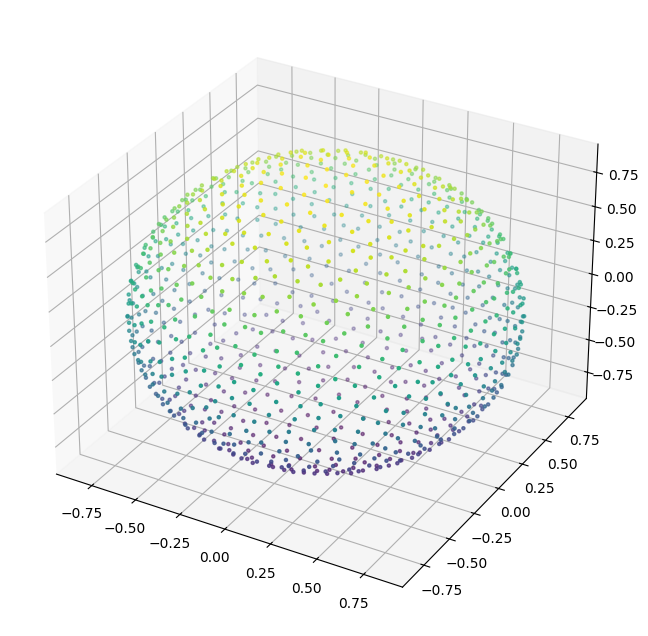

In [ ]:
import matplotlib.pyplot as plt

pc = new_point_cloud.squeeze().cpu().detach().numpy()

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=5, c=pc[:, 2], cmap='viridis')

max_range = (pc.max(axis=0) - pc.min(axis=0)).max() / 2.0
mid_x = (pc[:, 0].max() + pc[:, 0].min()) * 0.5
mid_y = (pc[:, 1].max() + pc[:, 1].min()) * 0.5
mid_z = (pc[:, 2].max() + pc[:, 2].min()) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()